# Pipeline stages — calling them individually

Every stage in PaddockTS is a plain Python function. `get_outputs(troi)` is just an orchestrator that calls them in order on two parallel threads with a live dashboard. For debugging, fine-tuning, or swapping in your own implementation of any step, you can call each stage directly.

Caching is built in — every stage writes a `_SUCCESS` marker after its data file completes, and re-running with the same `Troi` is a no-op (or a fast load from disk).

This notebook walks through the Sentinel-2 → PaddockTS chain stage by stage and shows how to inspect each intermediate output.

In [1]:
from datetime import date
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

from troi import Troi

troi = Troi(
    bbox=[148.36265, -33.52606, 148.38265, -33.50606],
    start=date(2024, 1, 1),
    end=date(2024, 12, 31),    # full year so phenology metrics are meaningful
    stub="stages_demo",
)
print(troi)

-----  --------------------------------------------
stub   stages_demo
bbox   [148.36265, -33.52606, 148.38265, -33.50606]
start  2024-01-01
end    2024-12-31
-----  --------------------------------------------


## 1. Download Sentinel-2 (`download_sentinel2`)

Sentinel-2 comes from the machine-wide [`pysentinel2`](https://github.com/thestochasticman/pysentinel2) cube: it searches the Digital Earth Australia STAC catalog (`ga_s2am_ard_3` / `ga_s2bm_ard_3`) and downloads **only the pixels no previous read has fetched** — coverage is tracked per day as exact pixel rectangles, so repeat and overlapping windows re-download nothing.

Returns an `xarray.Dataset` on `(time, y, x)` with the raw cube — DN values in `[0, 10000]`, plus the `oa_fmask` quality band.

In [2]:
from pysentinel2.cube import Cube

cube = Cube(config=troi.config)

ds = cube.get_ds_troi(troi)  # raw window incl. fmask
print(f"scenes: {ds.time.size}")
print(f"bands : {list(ds.data_vars)}")
print(f"shape : {dict(ds.sizes)}")

scenes: 124
bands : ['oa_fmask', 'nbart_blue', 'nbart_green', 'nbart_red', 'nbart_red_edge_1', 'nbart_red_edge_2', 'nbart_red_edge_3', 'nbart_nir_1', 'nbart_nir_2', 'nbart_swir_2', 'nbart_swir_3']
shape : {'time': 124, 'y': 215, 'x': 193}


## 2. Clean cloud + bad scenes (`clean_sentinel2`)

Cleaning is computed **on read** — nothing is stored twice. The fmask cloud/shadow (and snow) mask is dilated by `buffer_px` to catch cloud-edge halos, then frames are gated on `max_cloud_fraction` (contamination over *valid* pixels) and `min_valid_fraction` (swath coverage). Per-frame `cloud_fraction` / `valid_fraction` land as coordinates so you can see why frames survived.

In [3]:

ds_clean = cube.get_ds_troi(troi, clean=True, max_cloud_fraction=0.5)
print(f"scenes before: {ds.time.size}")
print(f"scenes after : {ds_clean.time.size}")
print(f"fmask removed: {'oa_fmask' not in ds_clean.data_vars}")

scenes before: 124
scenes after : 43
fmask removed: True


## 3. Compute spectral indices

NDVI, CFI, NIRv, NDTI and CAI are **on-read derivatives** of the cube — request them per call with `indices=`, store nothing (they imply `clean=True`).

added indices: ['NDVI', 'CFI', 'NIRv', 'NDTI', 'CAI']


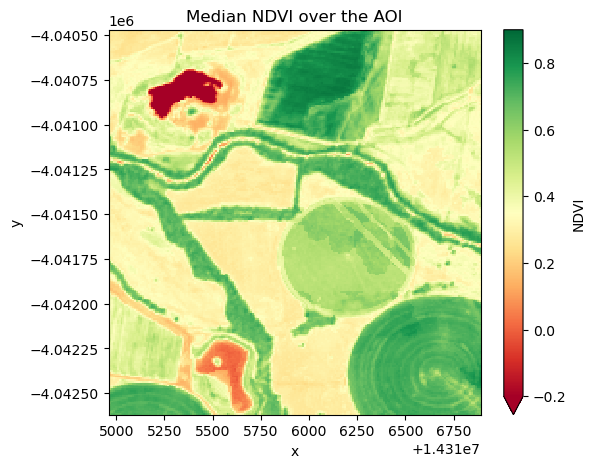

In [4]:

ds = cube.get_ds_troi(troi, clean=True, max_cloud_fraction=0.5,
                      indices=("NDVI", "CFI", "NIRv", "NDTI", "CAI"))
added = [v for v in ['NDVI', 'CFI', 'NIRv', 'NDTI', 'CAI'] if v in ds.data_vars]
print("added indices:", added)

# Median NDVI as a map
fig, ax = plt.subplots(figsize=(6, 5))
ds.NDVI.median(dim="time").plot.imshow(ax=ax, cmap="RdYlGn", vmin=-0.2, vmax=0.9)
ax.set_title("Median NDVI over the AOI")
plt.show()

## 4. Fractional cover (`compute_fractional_cover`)

Spectral unmixing of the six SR bands into bare ground (`bg`), green vegetation (`pv`), and non-green vegetation (`npv`) — per pixel, per timestep. Uses a TFLite MLP adapted from [`fractionalcover3`](https://github.com/jrsrp/fractionalcover3).

Visualised as a false-colour RGB: red = bare, green = growing, blue = stubble / dry.

In [5]:
from PaddockTS.FractionalCover import compute_fractional_cover

fc = compute_fractional_cover(troi, ds_sentinel2=ds_clean)
print(fc)

INFO: Initialized TensorFlow Lite runtime.
INFO: Applying 1 TensorFlow Lite delegate(s) lazily.
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
VERBOSE: XNNPack weight cache not enabled.
VERBOSE: Replacing 4 out of 4 node(s) with delegate (TfLiteXNNPackDelegate) node, yielding 1 partitions for subgraph 0.
INFO: Successfully applied the default TensorFlow Lite delegate indexed at 0.
 *NOTE*: because a delegate has been applied, the precision of computations should be unchanged, but the exact output tensor values may have changed. If such output values are checked in your code, like in your tests etc., please consider increasing error tolerance for the check.


<xarray.Dataset> Size: 21MB
Dimensions:  (time: 43, y: 215, x: 193)
Coordinates:
  * time     (time) datetime64[ns] 344B 2024-01-02 2024-01-12 ... 2024-12-27
  * y        (y) float64 2kB -4.04e+06 -4.04e+06 ... -4.043e+06 -4.043e+06
  * x        (x) float64 2kB 1.431e+07 1.431e+07 ... 1.432e+07 1.432e+07
Data variables:
    bg       (time, y, x) float32 7MB ...
    npv      (time, y, x) float32 7MB ...
    pv       (time, y, x) float32 7MB ...


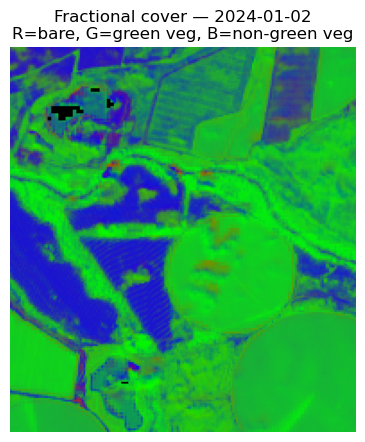

In [6]:
fc_t = fc.isel(time=0)
total = np.maximum(fc_t.bg + fc_t.pv + fc_t.npv, 1e-6)
rgb = np.stack([
    (fc_t.bg / total).values,
    (fc_t.pv / total).values,
    (fc_t.npv / total).values,
], axis=-1)
rgb = np.clip(np.nan_to_num(rgb), 0, 1)

fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(rgb)
ax.set_title(f"Fractional cover — {str(fc.time.values[0])[:10]}\n"
             "R=bare, G=green veg, B=non-green veg")
ax.axis('off')
plt.show()

## 5. Segment paddocks with SAM (`get_paddocks`)

Three internal steps:

1. **Presegmentation** — derive a single grayscale image from the Sentinel-2 stack using NDWI Fourier features (emphasises stable field boundaries).
2. **SAM** — feed the presegmented image to Segment Anything (ViT-H backbone; ~2.4 GB checkpoint auto-downloaded on first run).
3. **Filter** — explode, reproject to UTM, compute area + isoperimetric compactness, drop polygons outside `[min_area_ha, max_area_ha]` or below `min_compactness`.

Returns a `GeoDataFrame` with one row per paddock; also written to `Paths(troi).sam_paddocks`.

In [7]:
from PaddockTS.PaddockSegmentation.get_paddocks import get_paddocks

paddocks = get_paddocks(troi, ds_sentinel2=ds_clean)
print(f"{len(paddocks)} paddocks")
paddocks[["paddock", "area_ha", "compactness"]].head()

  Preseg: computing NDWI Fourier features...
  Preseg: done (0.1s)


Saved preseg to /Users/adeel/Downloads/Troi-Tmp/paddockts/ca9bacb92057da668884a5176351886574c1e9efe5b047801910102a83350d4c/553a0a0aecc4963a66972a7661e68b49999bcb0a82ed47ff6b70931ae5d4c56c/preseg.tif


/Users/adeel/miniconda3/envs/paddockts/lib/python3.11/site-packages/sam3/model/sam3_video_inference.py:798: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  @torch.autocast(device_type="cuda", dtype=torch.bfloat16)
/Users/adeel/miniconda3/envs/paddockts/lib/python3.11/site-packages/sam3/model/sam3_video_inference.py:906: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  @torch.autocast(device_type="cuda", dtype=torch.bfloat16)


  SAMGeo: loading model...


  SAMGeo: model loaded (17.7s)
  SAMGeo: generating masks...


...

100%|██████████| 1/1 [03:13<00:00, 193.50s/it]


  SAMGeo: masks generated (194.0s)
Warning 1: DeprecationWarning: 'Memory' driver is deprecated since GDAL 3.11. Use 'MEM' onwards. Further messages of this type will be suppressed.


13 paddocks


  Filtering polygons...
  13 paddocks saved to /Users/adeel/Downloads/Troi-Tmp/paddockts/ca9bacb92057da668884a5176351886574c1e9efe5b047801910102a83350d4c/553a0a0aecc4963a66972a7661e68b49999bcb0a82ed47ff6b70931ae5d4c56c/sam_paddocks.gpkg


,paddock,area_ha,compactness
0,1,37.615206,0.688290
1,2,31.157592,0.563134
2,3,30.247997,0.613843
3,4,26.249618,0.454171
4,5,25.189842,0.180656


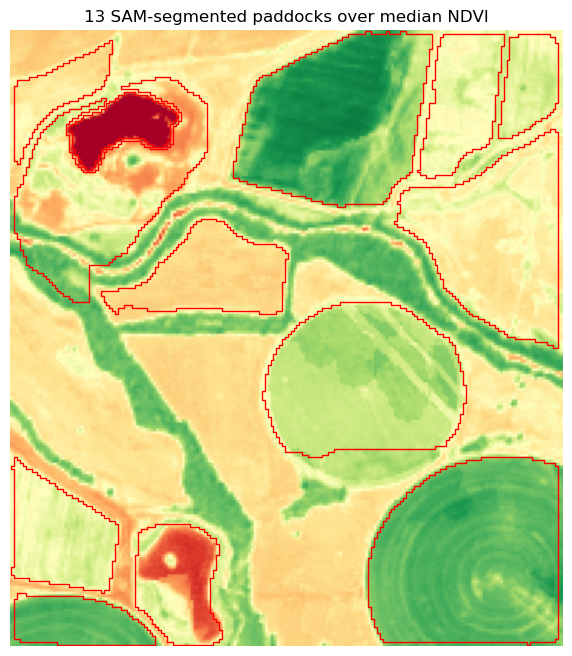

In [8]:
# Overlay the polygons on the median NDVI to eyeball segmentation quality
ndvi_med = ds.NDVI.median(dim="time")
extent = [float(ds.x.min()), float(ds.x.max()), float(ds.y.min()), float(ds.y.max())]

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(ndvi_med, cmap="RdYlGn", vmin=-0.1, vmax=0.9, extent=extent, origin="upper")
paddocks.boundary.plot(ax=ax, color="red", linewidth=1)
ax.set_title(f"{len(paddocks)} SAM-segmented paddocks over median NDVI")
ax.axis("off")
plt.show()

## 6. Per-paddock time series (`make_paddock_time_series`)

The pivot from pixel-space to paddock-space. Rasterises paddock polygons onto the S2 grid, then for every band computes the per-paddock NaN-aware median at each timestep. Output is an `xarray.Dataset` on `(paddock, time)` persisted as Zarr.

This is the central data product — downstream stages (yearly split, phenology, plots) all consume it.

In [9]:
from PaddockTS.Phenology.make_paddock_time_series import make_paddock_time_series

from PaddockTS.paths import Paths
ts = make_paddock_time_series(troi, ds_sentinel2=ds, paddocks_filepath=Paths(troi).sam_paddocks)
print(ts)

Saved to /Users/adeel/Downloads/Troi-Tmp/stages_demo/sam_paddocks_timeseries.zarr
<xarray.Dataset> Size: 82kB
Dimensions:           (paddock: 13, time: 43)
Coordinates:
  * paddock           (paddock) <U2 104B '1' '2' '3' '4' ... '10' '11' '12' '13'
  * time              (time) datetime64[ns] 344B 2024-01-02 ... 2024-12-27
    valid_fraction    (time) float64 344B 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0
    cloud_fraction    (time) float64 344B 0.0 0.3344 0.0 0.1082 ... 0.0 0.0 0.0
    snow_fraction     (time) float64 344B 0.0029 0.0008 0.0002 ... 0.0006 0.0004
    spatial_ref       int32 4B 6933
Data variables: (12/18)
    nbart_blue        (paddock, time) float64 4kB 309.0 993.5 ... 880.5 706.5
    nbart_green       (paddock, time) float64 4kB 560.0 1.194e+03 ... 1.111e+03
    nbart_red         (paddock, time) float64 4kB 266.0 1.115e+03 ... 1.154e+03
    nbart_red_edge_1  (paddock, time) float64 4kB 855.0 1.545e+03 ... 1.172e+03
    nbart_red_edge_2  (paddock, time) float64 4kB 3.855e+0

## 7. Yearly split + phenology

`make_yearly_paddock_time_series` splits the cube by calendar year and attaches a `doy` (day-of-year) coordinate. `estimate_phenology` wraps the vendored [`phenolopy`](https://github.com/lewistrotter/phenolopy) to derive SoS / PoS / EoS and friends per paddock per year.

In [10]:
from PaddockTS.Phenology.make_yearly_paddock_time_series import make_yearly_paddock_time_series
from PaddockTS.Phenology.estimate_phenology import estimate_phenology

yearly = make_yearly_paddock_time_series(troi, ds_paddockTS=ts)
phen = estimate_phenology(troi, ds_yearly=yearly, variable="NDVI")

for year, df in phen.items():
    print(f"\n=== {year} — {len(df)} paddocks ===")
    print(df[["paddock", "sos_times", "pos_times", "eos_times",
             "aos_values", "los_values", "num_peaks"]].head())

Saved 2024: 43 time steps -> /Users/adeel/Downloads/Troi-Tmp/stages_demo/sam_paddocks_timeseries_2024.zarr
Beginning calculation of number of seasons.
> Calculating number of seasons.
> Success!

Initialising calculation of phenometrics.

Beginning extraction of CRS metadata.
> Extracting CRS metadata.
> No CRS metadata found. Returning None.

Beginning calculation of phenometrics. This can take awhile - please wait.

Beginning calculation of peak of season (pos) values and times.
> Calculating peak of season (pos) values.
> Calculating peak of season (pos) times.
> Success!

Beginning calculation of valley of season (vos) values and times.
> Calculating valley of season (vos) values.
> Calculating valley of season (vos) times.
> Success!

Beginning calculation of middle of season (mos) values (times not possible).
> Calculating middle of season (mos) values.
> Success!

Beginning calculation of base (bse) values (times not possible).
> Calculating base (bse) values.
> Success!

Beginn

/Users/adeel/miniconda3/envs/paddockts/lib/python3.11/site-packages/xarray/core/duck_array_ops.py:268: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


## 8. Phenology curve for a single paddock

Plotted ourselves; for a multi-paddock × multi-year version see `PaddockTS.Plotting.phenology_plot`.

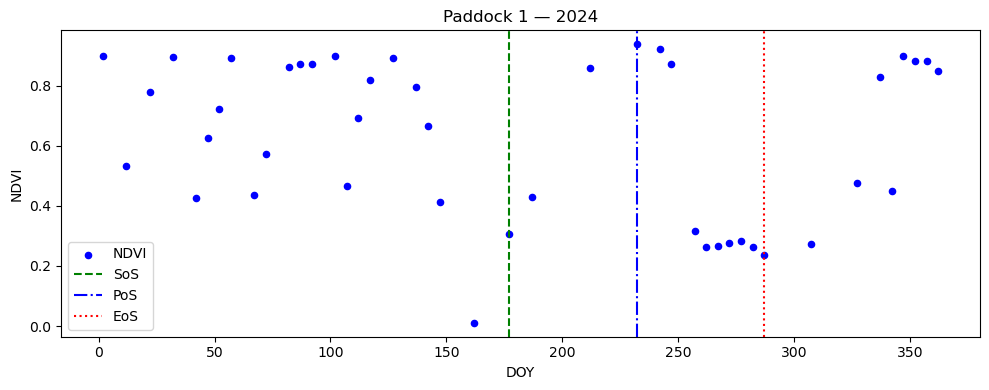

In [11]:
year = next(iter(phen))
df_year = phen[year]
ds_year = yearly[year]

paddock_id = ts.paddock.values[0]
row = df_year[df_year["paddock"].astype(str) == str(paddock_id)].iloc[0]

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(ds_year.doy, ds_year.NDVI.sel(paddock=paddock_id),
           color="blue", s=20, label="NDVI")
ax.axvline(row.sos_times, color="green", linestyle="--", label="SoS")
ax.axvline(row.pos_times, color="blue",  linestyle="-.", label="PoS")
ax.axvline(row.eos_times, color="red",   linestyle=":",  label="EoS")
ax.set_xlabel("DOY")
ax.set_ylabel("NDVI")
ax.set_title(f"Paddock {paddock_id} — {year}")
ax.legend()
plt.tight_layout()
plt.show()

## Caching contract

Every cached output is guarded by a `_SUCCESS` marker (a sibling file for GeoTIFFs / GeoPackages, an internal file inside the directory for Zarrs). On every stage's entry:

1. Check if the data file AND the `_SUCCESS` marker exist.
2. If yes, load from cache and return immediately.
3. If the data file exists but the marker is missing (e.g. previous run was killed mid-write), wipe the partial cache and re-run cleanly.

Re-run any of the cells above — the second call returns instantly from disk. To force a fresh rebuild, pass `reload=True` to `get_outputs` or delete the relevant path manually.

## See also

- [`01_quickstart.ipynb`](01_quickstart.ipynb) — the all-in-one `get_outputs(troi)` flow.
- [`03_custom_paddocks.ipynb`](03_custom_paddocks.ipynb) — skip SAM and use your own paddock boundaries.
- [API reference](https://thestochasticman.github.io/paddocktimeseries/api/) — every public function with examples.